In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import signal
from scipy.stats import skew, kurtosis
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.figsize"] = (12, 4)

DATA_PATH = "datos/dataset_horno_sostenimiento2_CORREGIDO.csv"


In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"]).set_index("timestamp").sort_index()
df.head()


,sensor_temp_main,sensor_temp_backup,setpoint,heater_power_pct,electrical_current,electrical_voltage,aluminum_level_pct,ambient_temp,energy_consumption_kwh,lid_open_pct,production_draw_rate
timestamp,,,,,,,,,,,
2026-05-01 00:00:00,696.428,693.800,700.000,47.734,57.492,440.282,82.000,20.015,0.72428,1.808,0.0
2026-05-01 00:01:00,696.268,693.790,700.004,47.734,57.492,440.541,81.996,18.730,0.74807,0.634,0.0
2026-05-01 00:02:00,696.114,693.780,700.009,45.622,55.593,441.401,82.041,18.984,0.71335,1.216,0.0
2026-05-01 00:03:00,695.990,693.758,700.013,47.724,56.809,439.804,82.030,19.478,0.71787,1.873,0.0
2026-05-01 00:04:00,695.817,693.733,700.017,46.657,57.217,441.053,82.015,19.272,0.73566,2.945,0.0


In [3]:
print(f"Shape: {df.shape}")
print(f"Rango: {df.index.min()} -> {df.index.max()}")
print(f"Frecuencia: {df.index.to_series().diff().median()}")
print(f"Duplicados en timestamp: {df.index.duplicated().sum()}")
print(f"Variables: {list(df.columns)}")


Shape: (20160, 11)
Rango: 2026-05-01 00:00:00 -> 2026-05-14 23:59:00
Frecuencia: 0 days 00:01:00
Duplicados en timestamp: 0
Variables: ['sensor_temp_main', 'sensor_temp_backup', 'setpoint', 'heater_power_pct', 'electrical_current', 'electrical_voltage', 'aluminum_level_pct', 'ambient_temp', 'energy_consumption_kwh', 'lid_open_pct', 'production_draw_rate']


In [4]:
OUTPUTS  = ["sensor_temp_main", "sensor_temp_backup"]
REF      = ["setpoint"]
CONTROL  = ["heater_power_pct"]
ELECTRIC = ["electrical_current", "electrical_voltage"]
DISTURB  = ["lid_open_pct", "ambient_temp", "production_draw_rate", "aluminum_level_pct"]
DERIVED  = ["energy_consumption_kwh"]
ALL_VARS = OUTPUTS + REF + CONTROL + ELECTRIC + DISTURB + DERIVED
df[ALL_VARS].describe().T.round(3)


,count,mean,std,min,25%,50%,75%,max
sensor_temp_main,19844.0,637.316,57.922,501.284,568.122,674.425,676.404,704.138
sensor_temp_backup,19954.0,634.391,57.597,509.628,566.988,671.505,673.370,693.800
setpoint,20160.0,700.000,0.707,699.000,699.293,700.000,700.707,701.000
heater_power_pct,20160.0,83.777,14.212,0.000,75.798,79.012,100.000,100.000
electrical_current,20160.0,90.264,13.732,0.000,83.130,86.441,103.889,110.596
electrical_voltage,20160.0,439.972,3.340,429.239,437.360,440.004,442.574,450.123
lid_open_pct,20160.0,3.764,6.259,0.000,1.462,2.102,2.818,50.037
ambient_temp,20160.0,24.002,3.553,17.925,20.474,23.996,27.517,30.059
production_draw_rate,20160.0,0.378,1.100,0.000,0.000,0.000,0.000,4.833
aluminum_level_pct,20160.0,90.305,8.413,30.557,90.412,93.452,93.993,94.000


In [5]:
null_summary = pd.DataFrame({
    "nulos": df.isna().sum(),
    "pct": (df.isna().mean() * 100).round(2),
})
null_summary


,nulos,pct
sensor_temp_main,316,1.57
sensor_temp_backup,206,1.02
setpoint,0,0.00
heater_power_pct,0,0.00
electrical_current,0,0.00
electrical_voltage,0,0.00
aluminum_level_pct,0,0.00
ambient_temp,0,0.00
energy_consumption_kwh,0,0.00
lid_open_pct,0,0.00


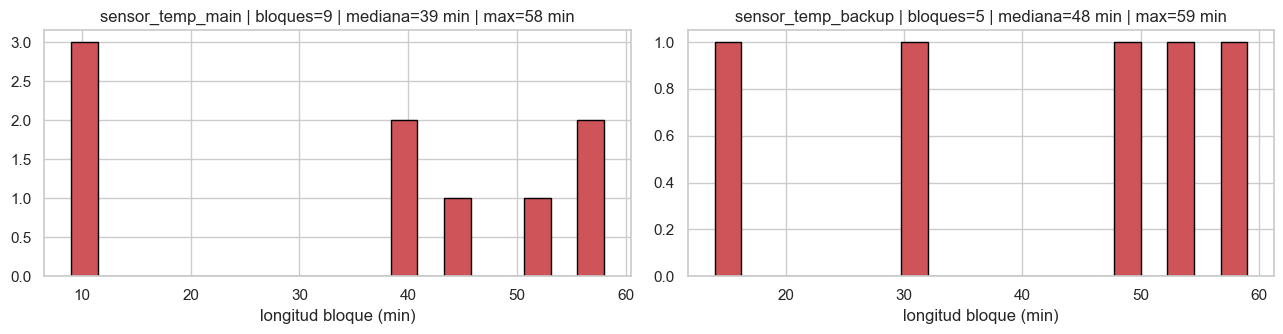

In [6]:
def null_runs(s):
    nulls = s.isna()
    groups = (nulls != nulls.shift()).cumsum()
    runs = nulls.groupby(groups).sum()
    return runs[runs > 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
for ax, col in zip(axes, ["sensor_temp_main", "sensor_temp_backup"]):
    runs = null_runs(df[col])
    if len(runs) > 0:
        ax.hist(runs, bins=20, edgecolor="black", color="#cf545a")
        ax.set_title(f"{col} | bloques={len(runs)} | mediana={runs.median():.0f} min | max={runs.max()} min")
    ax.set_xlabel("longitud bloque (min)")
plt.tight_layout(); plt.show()


In [7]:
def find_glitches(s, threshold=5.0):
    fwd = s.diff().abs()
    back = s.diff(-1).abs()
    return (fwd > threshold) & (back > threshold)

g_main = find_glitches(df["sensor_temp_main"])
g_backup = find_glitches(df["sensor_temp_backup"])
print(f"Glitches sensor_temp_main: {g_main.sum()}")
print(f"Glitches sensor_temp_backup: {g_backup.sum()}")


Glitches sensor_temp_main: 60
Glitches sensor_temp_backup: 14


In [8]:
key_vars = OUTPUTS + CONTROL + ELECTRIC + DISTURB
def iqr_outliers(s, k=3.0):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - k*iqr, q3 + k*iqr
    return ((s < lo) | (s > hi)).sum(), lo, hi

rows = []
for var in key_vars:
    n, lo, hi = iqr_outliers(df[var].dropna())
    rows.append([var, n, round(lo, 2), round(hi, 2)])
pd.DataFrame(rows, columns=["variable", "outliers_IQR3x", "lo", "hi"])


,variable,outliers_IQR3x,lo,hi
0,sensor_temp_main,0,243.27,1001.25
1,sensor_temp_backup,0,247.84,992.51
2,heater_power_pct,180,3.19,172.61
3,electrical_current,180,20.85,166.17
4,electrical_voltage,0,421.72,458.22
5,lid_open_pct,1750,-2.61,6.89
6,ambient_temp,0,-0.66,48.65
7,production_draw_rate,2342,0.00,0.00
8,aluminum_level_pct,1378,79.67,104.74


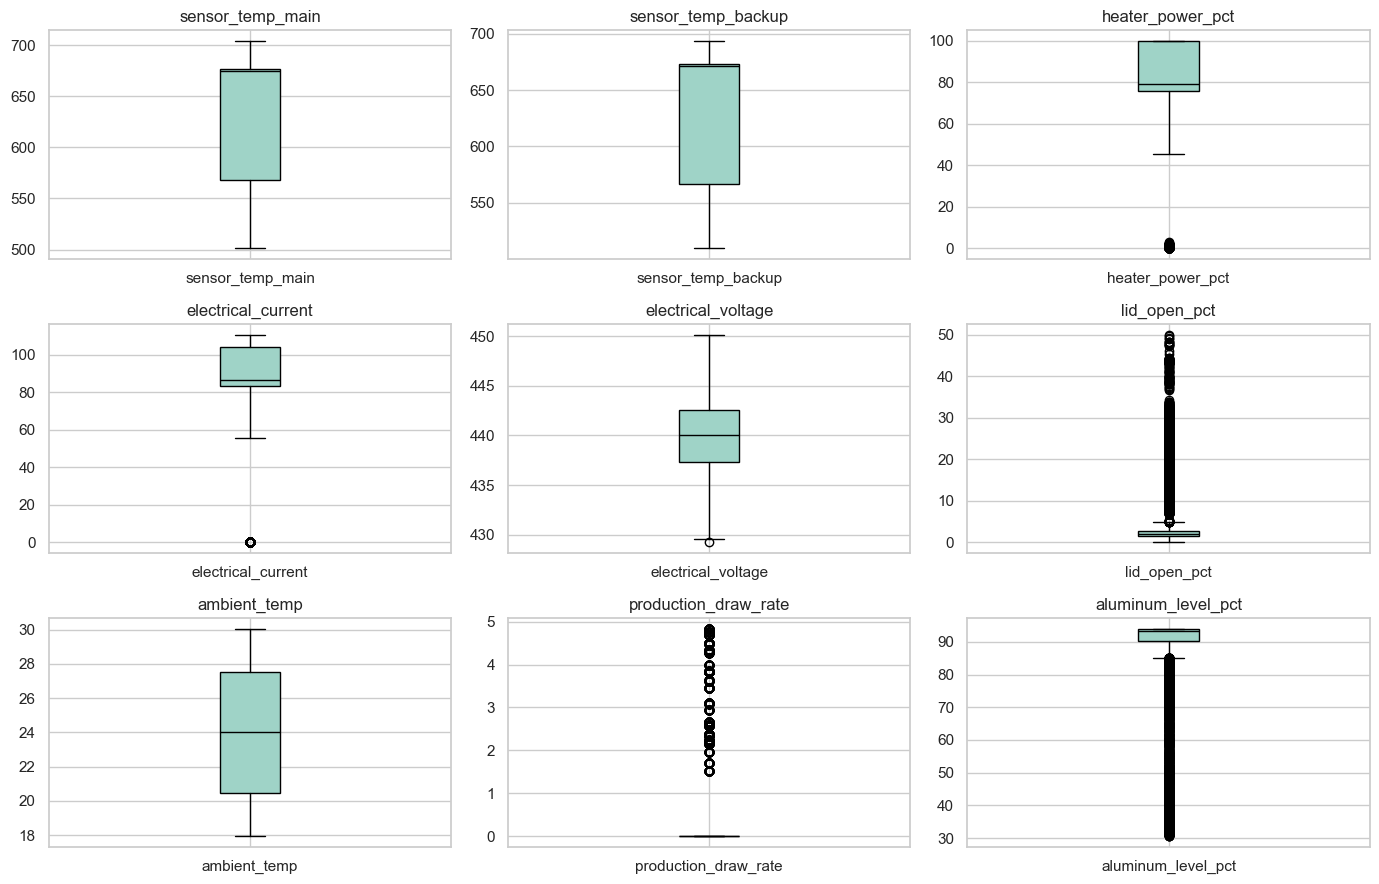

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(14, 9))
for ax, var in zip(axes.ravel(), key_vars):
    ax.boxplot(df[var].dropna(), labels=[var], patch_artist=True,
               boxprops=dict(facecolor="#9fd3c7"), medianprops=dict(color="black"))
    ax.set_title(var)
plt.tight_layout(); plt.show()


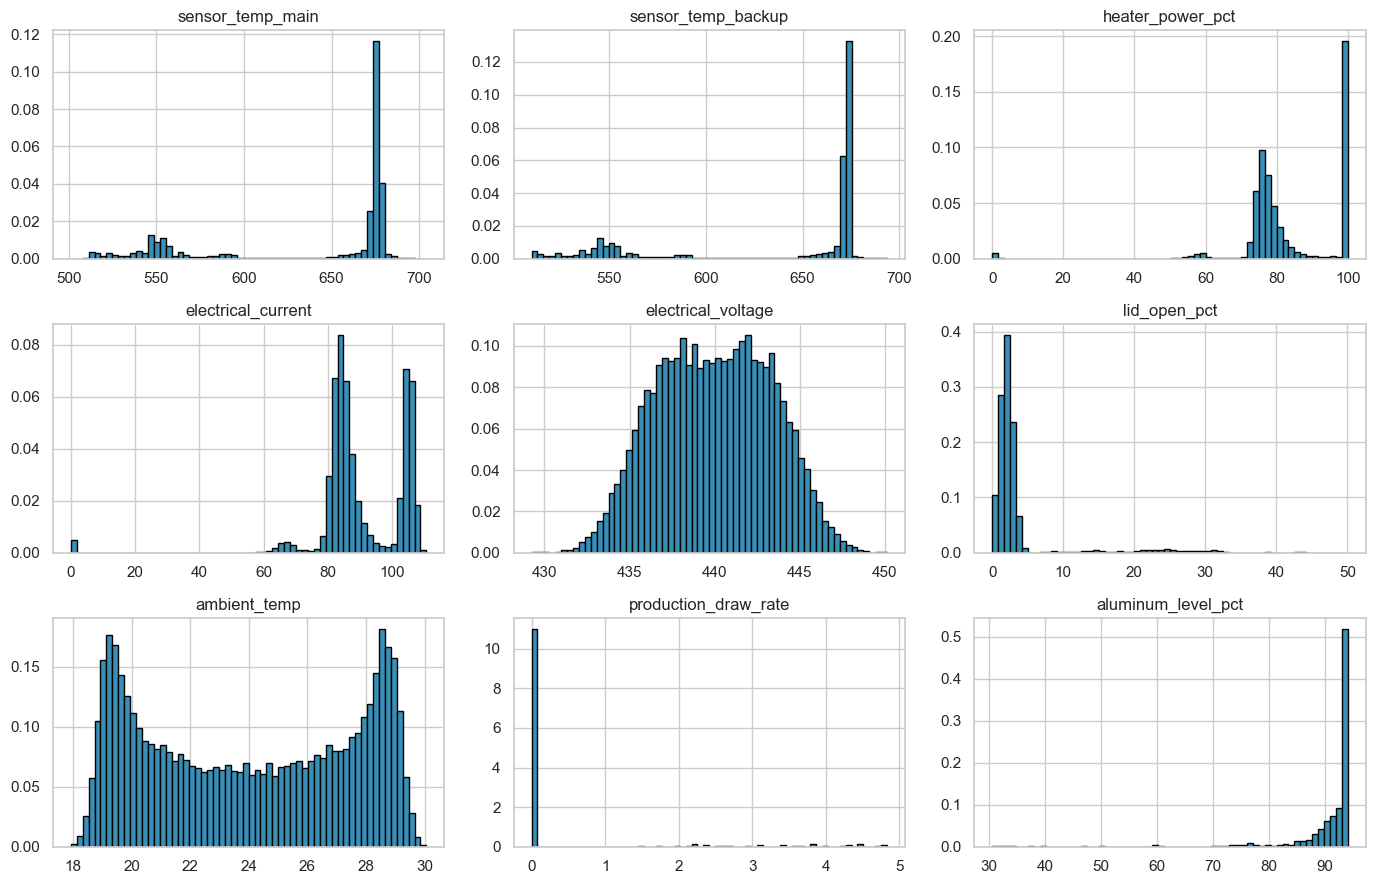

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(14, 9))
for ax, var in zip(axes.ravel(), key_vars):
    ax.hist(df[var].dropna(), bins=60, color="#3a8fb7", edgecolor="black", density=True)
    ax.set_title(var)
plt.tight_layout(); plt.show()


In [11]:
dist = pd.DataFrame({
    "skew": df[key_vars].skew().round(3),
    "kurt": df[key_vars].kurt().round(3),
})
dist


,skew,kurt
sensor_temp_main,-0.966,-0.880
sensor_temp_backup,-0.969,-0.877
heater_power_pct,-1.595,8.526
electrical_current,-2.344,14.403
electrical_voltage,-0.016,-0.724
lid_open_pct,3.619,13.266
ambient_temp,-0.002,-1.470
production_draw_rate,2.828,6.694
aluminum_level_pct,-4.201,20.281


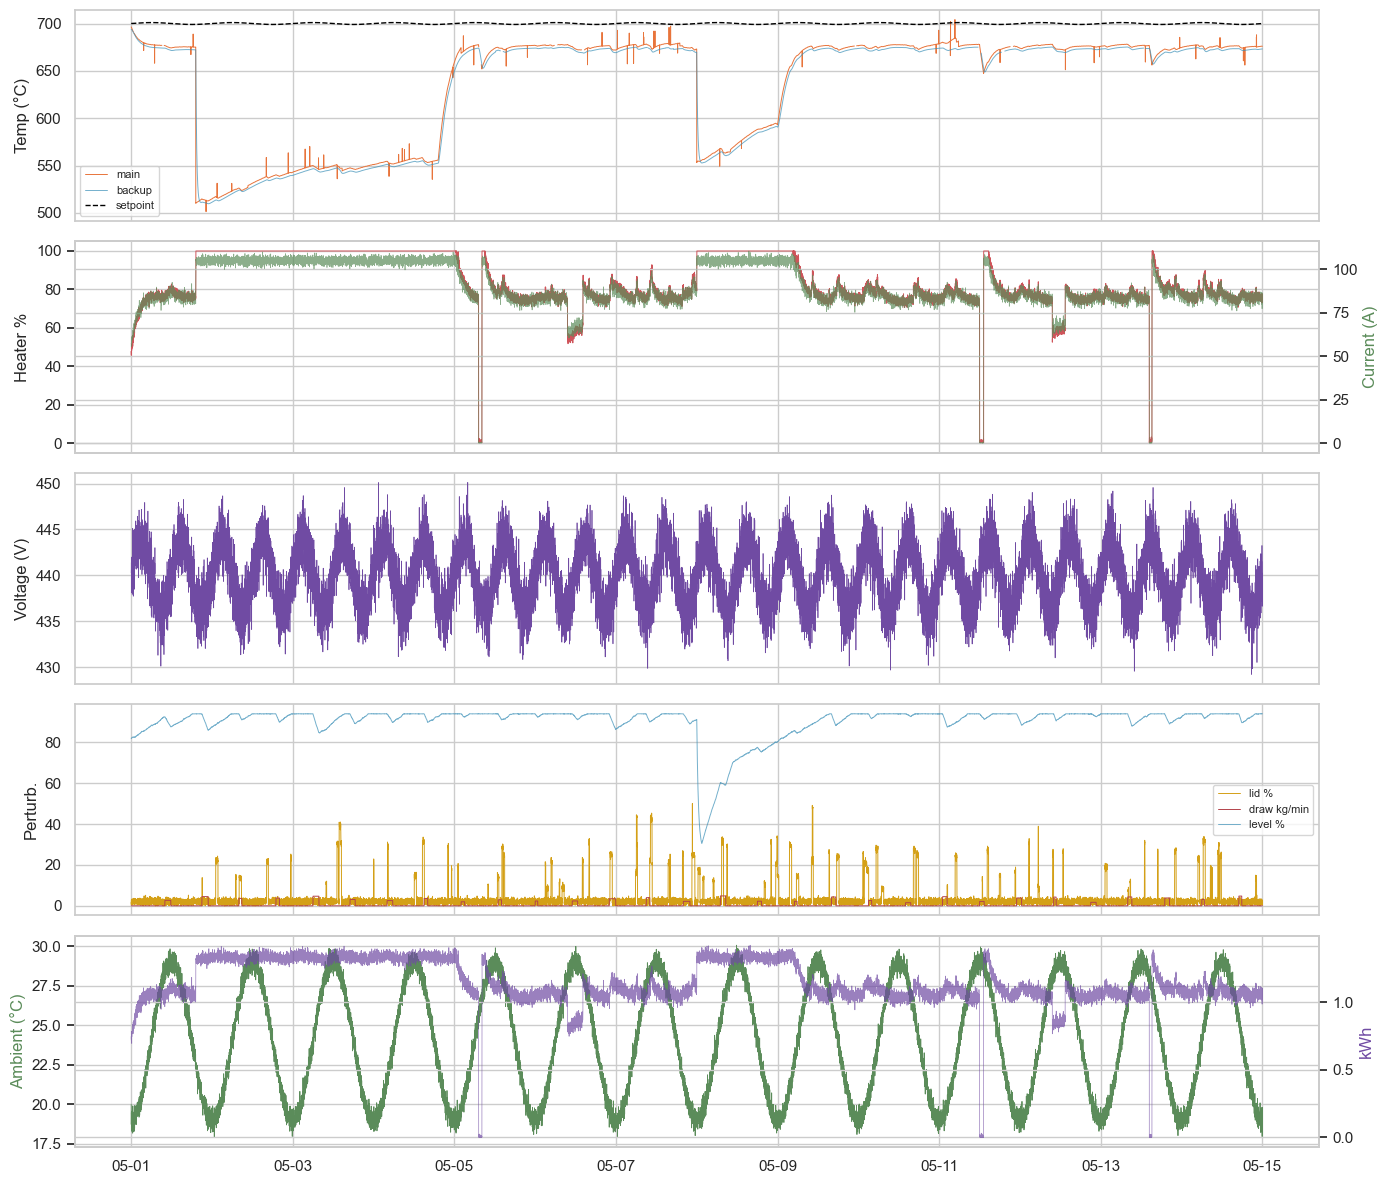

In [12]:
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
axes[0].plot(df.index, df["sensor_temp_main"], lw=0.7, label="main", color="#e8743b")
axes[0].plot(df.index, df["sensor_temp_backup"], lw=0.7, label="backup", color="#3a8fb7", alpha=0.7)
axes[0].plot(df.index, df["setpoint"], lw=1.0, label="setpoint", color="black", linestyle="--")
axes[0].set_ylabel("Temp (°C)"); axes[0].legend(fontsize=8)

axes[1].plot(df.index, df["heater_power_pct"], lw=0.7, color="#cf545a")
axes[1].set_ylabel("Heater %")
ax1b = axes[1].twinx()
ax1b.plot(df.index, df["electrical_current"], lw=0.5, color="#5b8c5a", alpha=0.7)
ax1b.set_ylabel("Current (A)", color="#5b8c5a")

axes[2].plot(df.index, df["electrical_voltage"], lw=0.5, color="#704ba3")
axes[2].set_ylabel("Voltage (V)")

axes[3].plot(df.index, df["lid_open_pct"], lw=0.7, color="#d4a017", label="lid %")
axes[3].plot(df.index, df["production_draw_rate"], lw=0.7, color="#b3424a", label="draw kg/min")
axes[3].plot(df.index, df["aluminum_level_pct"], lw=0.7, color="#3a8fb7", label="level %", alpha=0.7)
axes[3].set_ylabel("Perturb."); axes[3].legend(fontsize=8)

axes[4].plot(df.index, df["ambient_temp"], lw=0.6, color="#5b8c5a", label="ambient")
ax4b = axes[4].twinx()
ax4b.plot(df.index, df["energy_consumption_kwh"], lw=0.5, color="#704ba3", alpha=0.7)
axes[4].set_ylabel("Ambient (°C)", color="#5b8c5a")
ax4b.set_ylabel("kWh", color="#704ba3")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
plt.tight_layout(); plt.show()


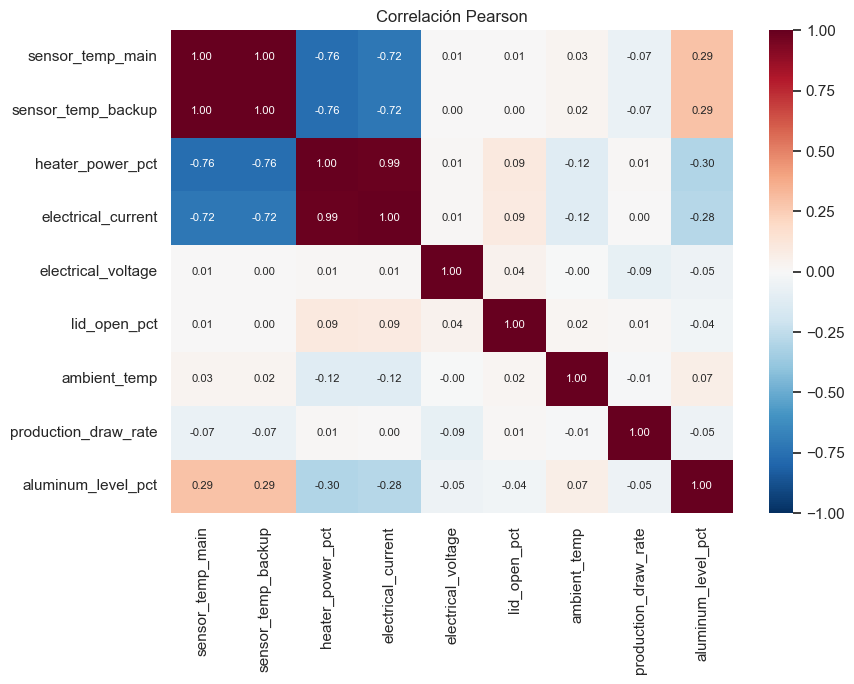

In [13]:
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[key_vars].corr(method="pearson")
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax, annot_kws={"size": 8})
ax.set_title("Correlación Pearson")
plt.tight_layout(); plt.show()


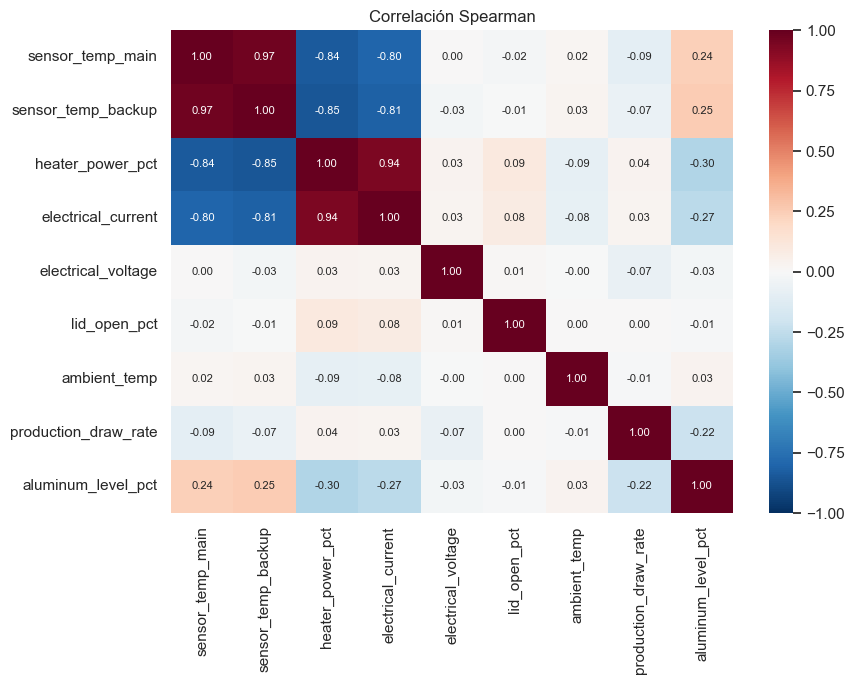

In [14]:
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[key_vars].corr(method="spearman")
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax, annot_kws={"size": 8})
ax.set_title("Correlación Spearman")
plt.tight_layout(); plt.show()


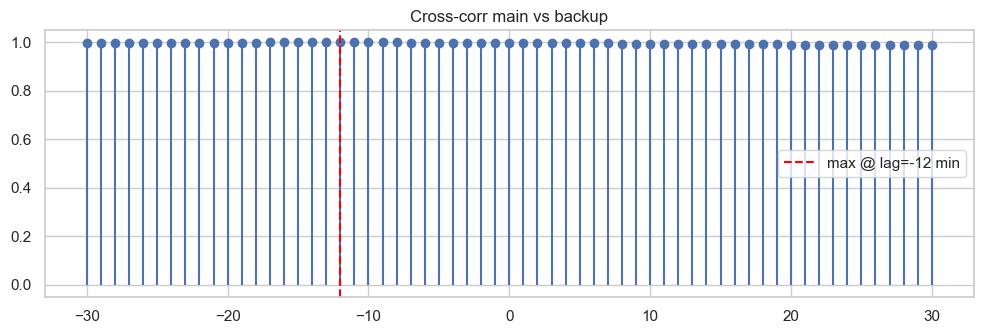

In [15]:
def cross_corr(x, y, max_lag=30):
    x = (x - x.mean()) / x.std()
    y = (y - y.mean()) / y.std()
    lags = np.arange(-max_lag, max_lag + 1)
    res = [np.corrcoef(x, y)[0, 1] if L == 0
           else (np.corrcoef(x[:L], y[-L:])[0, 1] if L < 0 else np.corrcoef(x[L:], y[:-L])[0, 1])
           for L in lags]
    return lags, np.array(res)

sub = df[["sensor_temp_main", "sensor_temp_backup"]].dropna()
lags, ccor = cross_corr(sub["sensor_temp_main"].values, sub["sensor_temp_backup"].values, max_lag=30)
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.stem(lags, ccor, basefmt=" ")
peak = lags[np.argmax(ccor)]
ax.axvline(peak, color="red", linestyle="--", label=f"max @ lag={peak} min")
ax.set_title("Cross-corr main vs backup"); ax.legend()
plt.tight_layout(); plt.show()


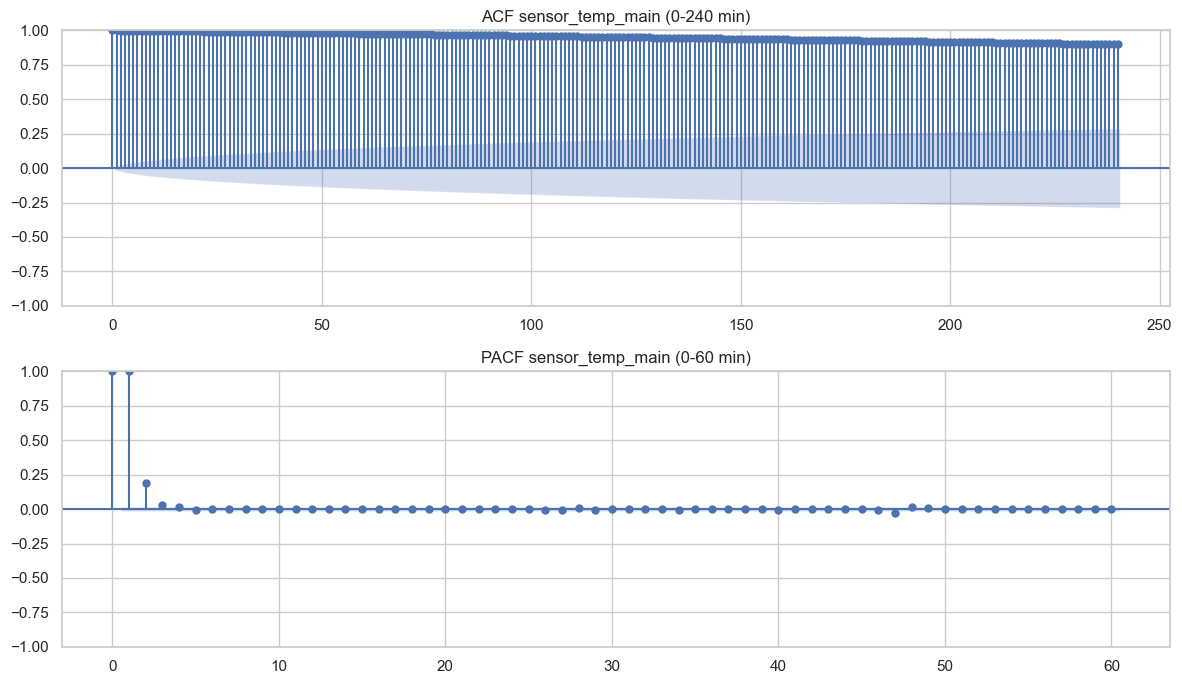

In [16]:
s_clean = df["sensor_temp_main"].interpolate(method="time", limit_direction="both")
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
plot_acf(s_clean, lags=240, ax=axes[0], title="ACF sensor_temp_main (0-240 min)")
plot_pacf(s_clean, lags=60, ax=axes[1], method="ywm", title="PACF sensor_temp_main (0-60 min)")
plt.tight_layout(); plt.show()


In [17]:
acf_vals = acf(s_clean, nlags=720, fft=True)
below05 = np.where(np.abs(acf_vals) < 0.5)[0]
below02 = np.where(np.abs(acf_vals) < 0.2)[0]
l05 = below05[0] if len(below05) else None
l02 = below02[0] if len(below02) else None
print(f"ACF < 0.5 en lag = {l05} min")
print(f"ACF < 0.2 en lag = {l02} min")


ACF < 0.5 en lag = None min
ACF < 0.2 en lag = None min


In [18]:
result = adfuller(s_clean.values, autolag="AIC")
print(f"ADF stat: {result[0]:.4f}")
print(f"p-value: {result[1]:.4e}")
print("Estacionaria" if result[1] < 0.05 else "NO estacionaria")


ADF stat: -1.8622
p-value: 3.5004e-01
NO estacionaria


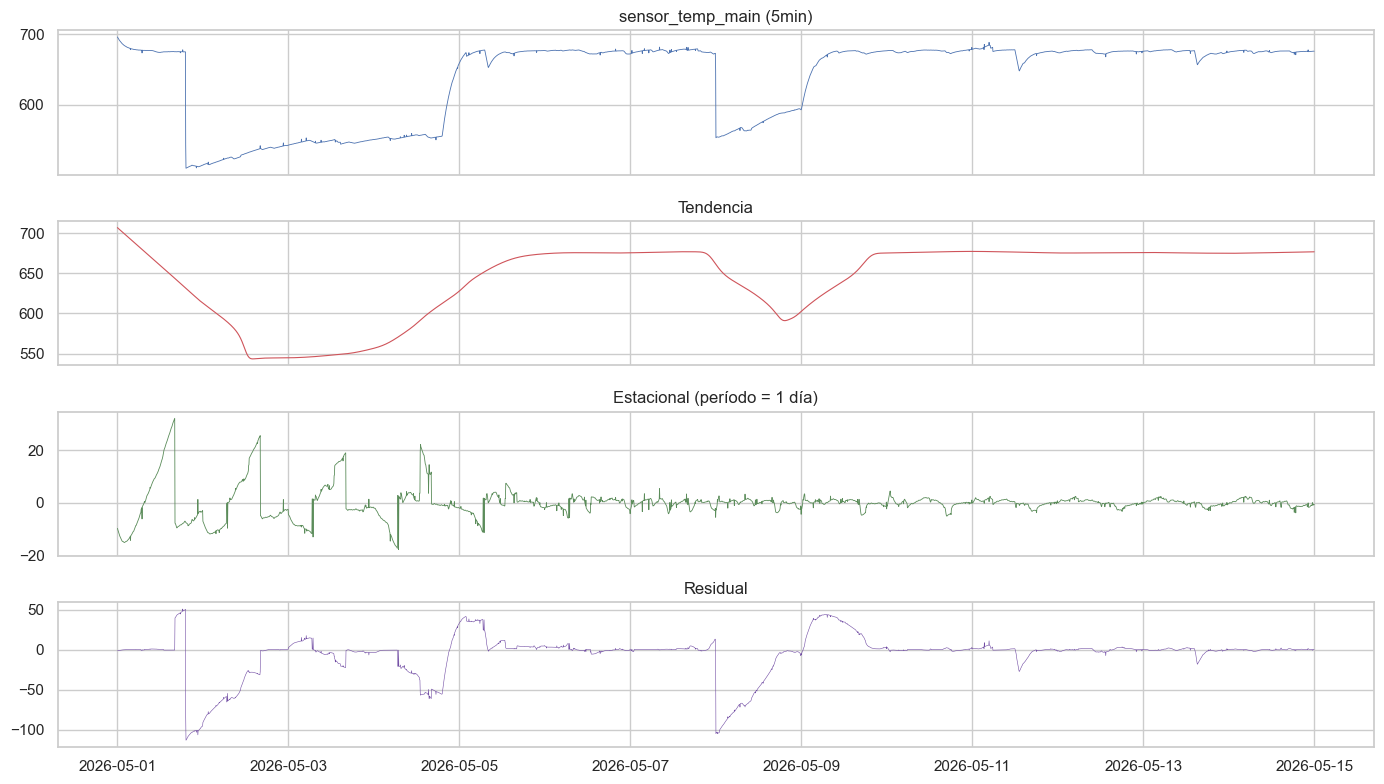

In [19]:
s_5min = s_clean.resample("5min").mean()
stl = STL(s_5min, period=288, robust=True).fit()
fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)
axes[0].plot(s_5min.index, s_5min.values, lw=0.6)
axes[0].set_title("sensor_temp_main (5min)")
axes[1].plot(stl.trend.index, stl.trend.values, color="#cf545a", lw=0.8)
axes[1].set_title("Tendencia")
axes[2].plot(stl.seasonal.index, stl.seasonal.values, color="#5b8c5a", lw=0.6)
axes[2].set_title("Estacional (período = 1 día)")
axes[3].plot(stl.resid.index, stl.resid.values, color="#704ba3", lw=0.4)
axes[3].set_title("Residual")
plt.tight_layout(); plt.show()


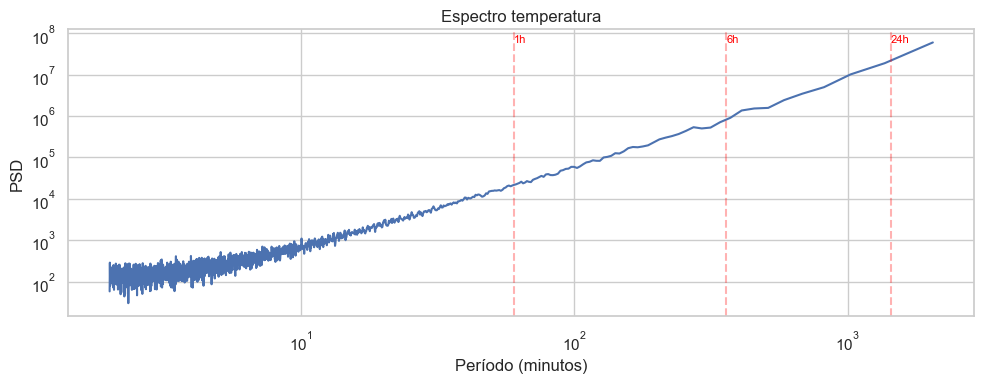

In [20]:
fig, ax = plt.subplots(figsize=(10, 4))
fs = 1/60
f, Pxx = signal.welch(s_clean.values - s_clean.mean(), fs=fs, nperseg=4096)
period_min = 1/(f * 60)
mask = (period_min > 1) & (period_min < 60*24*2)
ax.semilogy(period_min[mask], Pxx[mask])
ax.set_xscale("log")
ax.set_xlabel("Período (minutos)"); ax.set_ylabel("PSD")
ax.set_title("Espectro temperatura")
for p, lbl in [(60, "1h"), (360, "6h"), (1440, "24h")]:
    ax.axvline(p, color="red", linestyle="--", alpha=0.3)
    ax.text(p, ax.get_ylim()[1]*0.5, lbl, fontsize=8, color="red")
plt.tight_layout(); plt.show()


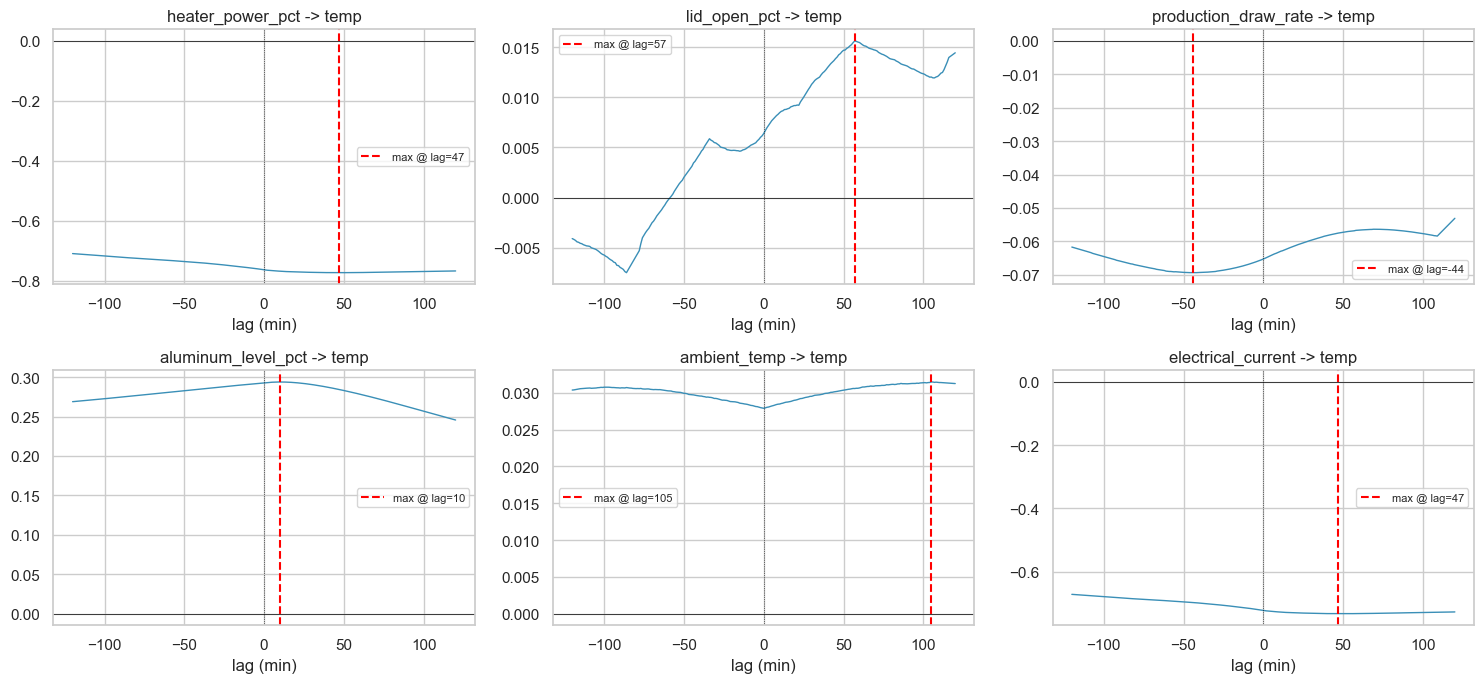

In [21]:
def ccf(df, ax, src, tgt, max_lag=120, title=""):
    sub = df[[src, tgt]].dropna()
    x = (sub[src].values - sub[src].mean()) / sub[src].std()
    y = (sub[tgt].values - sub[tgt].mean()) / sub[tgt].std()
    lags = np.arange(-max_lag, max_lag + 1)
    res = [np.corrcoef(x, y)[0,1] if L==0
           else (np.corrcoef(x[:L], y[-L:])[0,1] if L<0 else np.corrcoef(x[L:], y[:-L])[0,1])
           for L in lags]
    res = np.array(res)
    ax.plot(lags, res, color="#3a8fb7", lw=1.0)
    ax.axhline(0, color="black", lw=0.5)
    ax.axvline(0, color="black", linestyle=":", lw=0.5)
    best = lags[np.argmax(np.abs(res))]
    ax.axvline(best, color="red", linestyle="--", label=f"max @ lag={best}")
    ax.set_title(title); ax.set_xlabel("lag (min)"); ax.legend(fontsize=8)

inputs_to_check = [
    "heater_power_pct", "lid_open_pct", "production_draw_rate",
    "aluminum_level_pct", "ambient_temp", "electrical_current",
]
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, var in zip(axes.ravel(), inputs_to_check):
    ccf(df, ax, var, "sensor_temp_main", title=f"{var} -> temp")
plt.tight_layout(); plt.show()


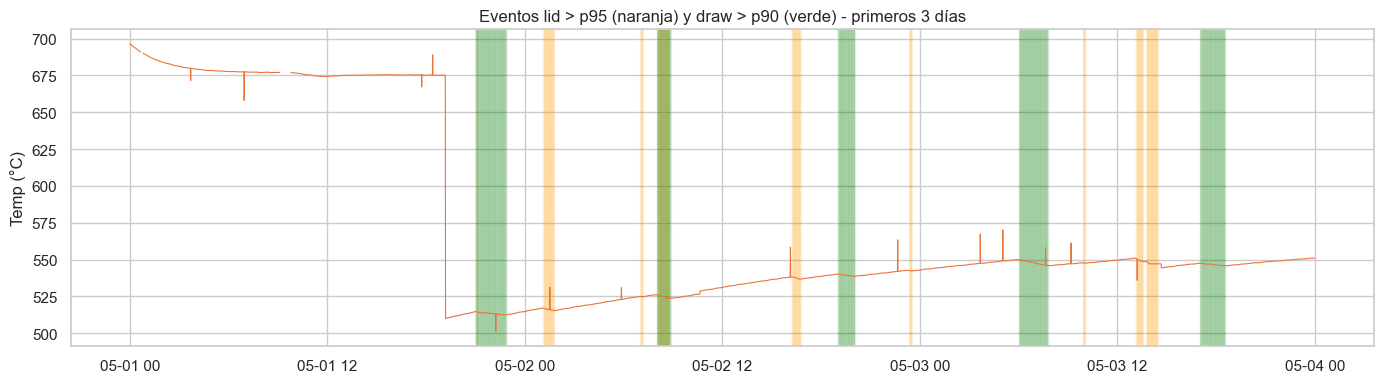

In [22]:
sub = df.iloc[:3*24*60].copy()
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(sub.index, sub["sensor_temp_main"], lw=0.8, color="#e8743b")
ev_lid = sub["lid_open_pct"] > sub["lid_open_pct"].quantile(0.95)
ev_draw = sub["production_draw_rate"] > sub["production_draw_rate"].quantile(0.90)
for t in sub.index[ev_lid]:
    ax.axvspan(t, t + pd.Timedelta("1min"), alpha=0.06, color="orange")
for t in sub.index[ev_draw]:
    ax.axvspan(t, t + pd.Timedelta("1min"), alpha=0.06, color="green")
ax.set_title("Eventos lid > p95 (naranja) y draw > p90 (verde) - primeros 3 días")
ax.set_ylabel("Temp (°C)")
plt.tight_layout(); plt.show()


In [23]:
n = len(df)
i_train = int(n * 0.70)
i_val = i_train + int(n * 0.15)
tr, va, te = df.iloc[:i_train], df.iloc[i_train:i_val], df.iloc[i_val:]
print(f"Train: {len(tr)} | {tr.index.min().date()} -> {tr.index.max().date()}")
print(f"Val:   {len(va)} | {va.index.min().date()} -> {va.index.max().date()}")
print(f"Test:  {len(te)} | {te.index.min().date()} -> {te.index.max().date()}")


Train: 14112 | 2026-05-01 -> 2026-05-10
Val:   3024 | 2026-05-10 -> 2026-05-12
Test:  3024 | 2026-05-12 -> 2026-05-14
